In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('bicep_curl_1.csv')

df.head()

Matplotlib is building the font cache; this may take a moment.


,timestamp,ax,ay,az,gx,gy,gz
0,1271909.0,0.272,0.307,0.928,1.770,3.662,1.587
1,1271929.0,0.253,0.341,0.885,-1.160,4.333,-1.099
2,1271949.0,0.253,0.323,0.907,0.122,4.517,4.211
3,1271969.0,0.259,0.300,0.923,0.671,5.371,4.211
4,1271989.0,0.260,0.329,0.899,0.366,4.211,1.160


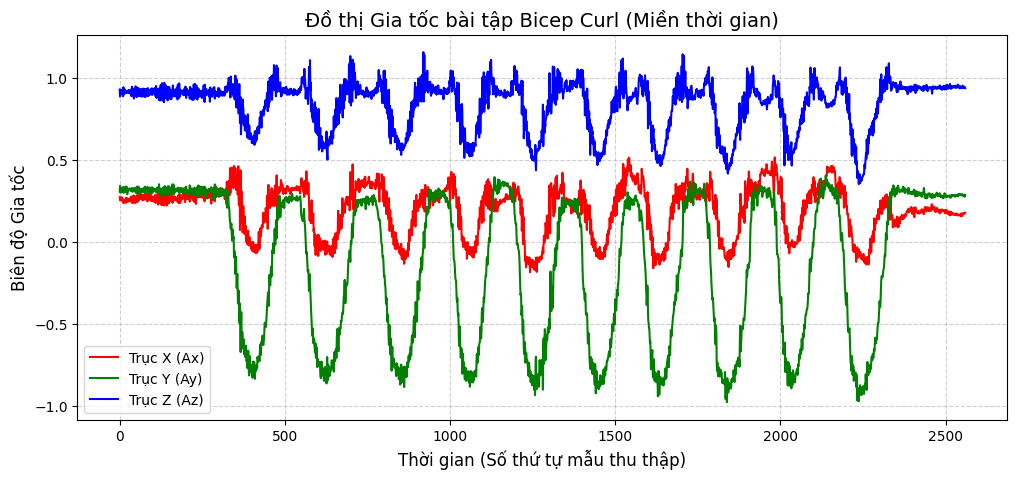

In [8]:
# Tạo một khung tranh (Figure) kích thước chiều rộng 12, chiều cao 5
plt.figure(figsize=(12, 5))

# Vẽ 3 đường đồ thị cho 3 trục gia tốc (X, Y, Z)
# Lưu ý: Nếu tên cột trong bảng của bạn viết hoa (như 'Ax', 'Ay'), hãy sửa lại chữ 'ax' ở dưới cho khớp nhé!
plt.plot(df['ax'], label='Trục X (Ax)', color='red')
plt.plot(df['ay'], label='Trục Y (Ay)', color='green')
plt.plot(df['az'], label='Trục Z (Az)', color='blue')

# Trang trí cho biểu đồ dễ nhìn hơn
plt.title('Đồ thị Gia tốc bài tập Bicep Curl (Miền thời gian)', fontsize=14)
plt.xlabel('Thời gian (Số thứ tự mẫu thu thập)', fontsize=12)
plt.ylabel('Biên độ Gia tốc', fontsize=12)
plt.legend() # Hiển thị bảng chú thích màu sắc
plt.grid(True, linestyle='--', alpha=0.6) # Bật lưới nền cho dễ căn sóng

# Lệnh chốt hạ: In bức tranh ra màn hình!
plt.show()

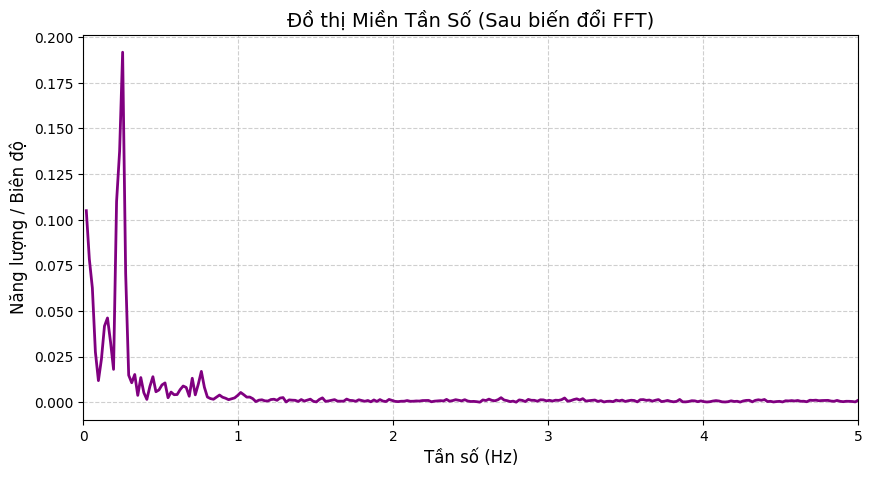

In [9]:
import numpy as np

# 1. Lấy dữ liệu của 1 trục biến thiên mạnh nhất (ví dụ Trục Y)
y_data = df['ay'].values 

# 2. Các thông số cơ bản
fs = 50.0  # Tần số lấy mẫu của ESP32 là 50Hz (50 mẫu/giây)
N = len(y_data) # Tổng số lượng mẫu dữ liệu

# 3. Thực hiện phép biến đổi Fourier nhanh (FFT)
# Đây chính là khối Spectral Analysis mà Edge Impulse đã làm ngầm!
yf = np.fft.fft(y_data)
xf = np.fft.fftfreq(N, 1/fs)

# Chỉ lấy một nửa đồ thị (vì FFT luôn đối xứng)
xf_half = xf[:N//2]
yf_half = np.abs(yf[:N//2]) / N

# Bỏ đi giá trị tại 0Hz (thành phần trọng lực DC tĩnh) để nhìn rõ chuyển động động
xf_half = xf_half[1:]
yf_half = yf_half[1:]

# 4. Vẽ đồ thị Miền Tần Số
plt.figure(figsize=(10, 5))
plt.plot(xf_half, yf_half, color='purple', linewidth=2)

plt.title('Đồ thị Miền Tần Số (Sau biến đổi FFT)', fontsize=14)
plt.xlabel('Tần số (Hz)', fontsize=12)
plt.ylabel('Năng lượng / Biên độ', fontsize=12)
plt.xlim(0, 5) # Chỉ zoom vào xem từ 0 đến 5Hz (vì người không thể vung tay nhanh hơn 5Hz)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [13]:
!pip install scipy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


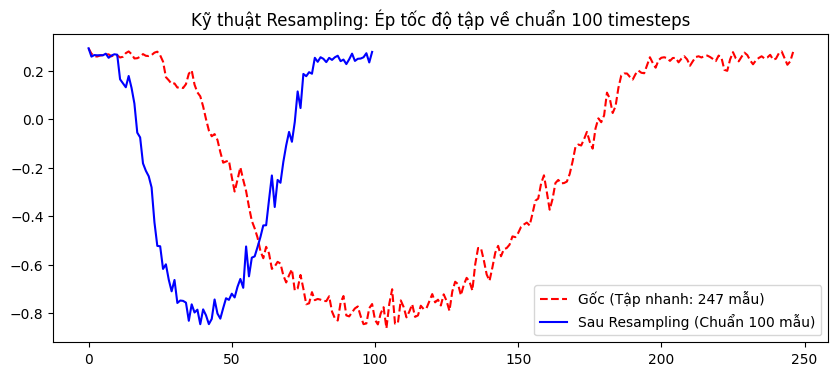

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

# Giả sử df là bảng dữ liệu của bạn, lấy trục Ay
y_data = df['ay'].values

# --- BƯỚC 1: DÒ ĐỈNH (PEAK DETECTION) ---
# Tìm các đỉnh cao, cách nhau ít nhất 50 mẫu (1 giây), độ nổi bật > 0.5
peaks, _ = find_peaks(y_data, distance=50, prominence=0.5)

# --- BƯỚC 2: CẮT VÀ LẤY MẪU LẠI (RESAMPLING) ---
# Lấy nhịp gập tạ đầu tiên (từ đỉnh số 1 đến đỉnh số 2)
nhip_dau_tien = y_data[peaks[0]:peaks[1]]
so_mau_hien_tai = len(nhip_dau_tien)

# Trục X cũ (từ 0 đến số mẫu hiện tại)
x_old = np.linspace(0, 1, so_mau_hien_tai)
# Trục X mới (ép về đúng 100 mẫu chuẩn)
x_new = np.linspace(0, 1, 100)

# Hàm nội suy tuyến tính
ham_noi_suy = interp1d(x_old, nhip_dau_tien, kind='cubic')
nhip_chuan_hoa = ham_noi_suy(x_new)

# --- VẼ BIỂU ĐỒ SO SÁNH ---
plt.figure(figsize=(10, 4))
plt.plot(nhip_dau_tien, label=f'Gốc (Tập nhanh: {so_mau_hien_tai} mẫu)', color='red', linestyle='--')
plt.plot(nhip_chuan_hoa, label='Sau Resampling (Chuẩn 100 mẫu)', color='blue')
plt.title('Kỹ thuật Resampling: Ép tốc độ tập về chuẩn 100 timesteps')
plt.legend()
plt.show()

In [15]:
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Concatenate, Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model

# Cửa ngõ đầu vào: Ma trận 100 mốc thời gian, 6 trục cảm biến
input_layer = Input(shape=(100, 6))

# --- TẠO 3 NHÁNH CHẠY SONG SONG ---
# Nhánh 1: Kính lúp nhỏ (Kernel 3)
branch_1 = Conv1D(filters=16, kernel_size=3, activation='relu', padding='same')(input_layer)
branch_1 = MaxPooling1D(pool_size=2)(branch_1)

# Nhánh 2: Kính lúp vừa (Kernel 7)
branch_2 = Conv1D(filters=16, kernel_size=7, activation='relu', padding='same')(input_layer)
branch_2 = MaxPooling1D(pool_size=2)(branch_2)

# Nhánh 3: Kính lúp lớn (Kernel 15)
branch_3 = Conv1D(filters=16, kernel_size=15, activation='relu', padding='same')(input_layer)
branch_3 = MaxPooling1D(pool_size=2)(branch_3)

# --- GỘP NHÁNH VÀ PHÂN LOẠI ---
# Gom kết quả của 3 nhánh lại làm 1
merged = Concatenate(axis=-1)([branch_1, branch_2, branch_3])

# Duỗi thẳng và chốt hạ
flat = Flatten()(merged)
dense = Dense(32, activation='relu')(flat)
output_layer = Dense(2, activation='softmax')(dense) # 2 nhãn: bicep_curl và idle

# Khởi tạo mô hình
multi_scale_model = Model(inputs=input_layer, outputs=output_layer)

# In cấu trúc mạng ra xem
multi_scale_model.summary()

ModuleNotFoundError: No module named 'tensorflow'

In [16]:
!pip install tensorflow

ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tensorflow
